In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import datetime


from src.analytics.aws_function_logs import AWSFunctionLogs
from src.profiler.cost_calculator import CostCalculator
from src.modeling.function_performance_modeling import FunctionPerformanceModeling
from src.profiler.explorer import Explorer

In [27]:
payload = '{"bucket_name": "test-images-mohammad", "num_images": 16, "batch_size": 4}'
region_name = 'us-east-1'

memeory_bounds = [(2000, 10000), (2000, 10000), (2000, 10000), (2000, 10000), (2000, 10000)]
available_models=["yolov10n", "yolov10s", "yolov10m", "yolov10l", "yolov10x"]
memory_space_step = 64

function_name = f"sam-yolo-InferenceFunctionYOLO-uDET6Qnlkvk2"

In [17]:
p_model = FunctionPerformanceModeling(
    function_name=function_name,
    payload=payload,
    memory_bounds=memeory_bounds,
    memory_space_step=memory_space_step,
    profiling_iterations=2,
    available_models=available_models,
)
o_memory = p_model.get_optimal_memory()
print(f"Optimal memory for {function_name} is {o_memory}")
duration_per_memory = {}
for model in available_models:
    duration_per_memory[model] = p_model.get_performance_model_as_function(model_name=model)
del p_model

2025-04-13 23:49:59 - src.utils.logger - WARNING - Concurrent Update Function Error. Retrying ...


Explored memories: [7632 7632 8272 8272 9872 9872]
Sample Count:  6
Max Sample Count:  20
Memories:  [7632 7632 8272 8272 9872 9872]
Duration:  [1103. 1181. 1340. 1315.  981. 1002.]
Value and Threshold:  1.0 3


C:\NonOneDrive\PACS_Lab\Serverless-ML-Workflow-Optimizer\src\optimizer\parametric_function.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  self.params = curve_fit(


Sample Count:  8
Max Sample Count:  20
Memories:  [2000 2000 7632 7632 8272 8272 9872 9872]
Duration:  [3687. 3699. 1103. 1181. 1340. 1315.  981. 1002.]
Value and Threshold:  2.0 3
Sample Count:  10
Max Sample Count:  20
Memories:  [2000 2000 2640 2640 7632 7632 8272 8272 9872 9872]
Duration:  [3687. 3699. 3546. 3765. 1103. 1181. 1340. 1315.  981. 1002.]
Value and Threshold:  2.005976022895006 3
Sample Count:  12
Max Sample Count:  20
Memories:  [2000 2000 2640 2640 7632 7632 8272 8272 9232 9232 9872 9872]
Duration:  [3687. 3699. 3546. 3765. 1103. 1181. 1340. 1315. 1211. 1188.  981. 1002.]
Value and Threshold:  2.005976022895006 3
Sample Count:  14
Max Sample Count:  20
Memories:  [2000 2000 2640 2640 3280 3280 7632 7632 8272 8272 9232 9232 9872 9872]
Duration:  [3687. 3699. 3546. 3765. 2361. 2401. 1103. 1181. 1340. 1315. 1211. 1188.
  981. 1002.]
Value and Threshold:  2.0059760241704137 3
Sample Count:  16
Max Sample Count:  20
Memories:  [2000 2000 2640 2640 3280 3280 4048 4048 7632 

In [28]:
explorer = Explorer(
    function_name=function_name,
    payload=payload,
    boto_session=boto3.Session(region_name=region_name),
    memory_space_step=memory_space_step,
    max_invocations=5,
    available_models = available_models,
    memory_bounds=memeory_bounds
)

explorer.explore_all_memories(num_of_invocations=1)

Processing: 100%|██████████ [Elapsed: 39:37 | Remaining: 00:00]
Processing: 100%|██████████ [Elapsed: 49:25 | Remaining: 00:00]
Processing: 100%|██████████ [Elapsed: 1:12:05 | Remaining: 00:00]
Processing: 100%|██████████ [Elapsed: 1:45:12 | Remaining: 00:00]
Processing: 100%|██████████ [Elapsed: 2:10:53 | Remaining: 00:00]  


In [29]:
aws_logs = AWSFunctionLogs(
    boto_session=boto3.Session(region_name=region_name),
    function_name=function_name,
    docker_deploy=True
)

for model in available_models:
    df = aws_logs.get_logs_df(start_time=int((datetime.datetime.utcnow() - datetime.timedelta(days=1)).timestamp()),
    end_time=int(datetime.datetime.utcnow().timestamp()), model_name=model)

    df.to_csv(f'{function_name}_{model}_logs.csv')

C:\Users\MoeHosseini\AppData\Local\Temp\ipykernel_24168\719281483.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  df = aws_logs.get_logs_df(start_time=int((datetime.datetime.utcnow() - datetime.timedelta(days=1)).timestamp()),
C:\Users\MoeHosseini\AppData\Local\Temp\ipykernel_24168\719281483.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_time=int(datetime.datetime.utcnow().timestamp()), model_name=model)


In [30]:
cost_calculator = CostCalculator(
    function_name=function_name,
)

In [31]:
dfs = {}
for model in available_models:
    dfs[model] = pd.read_csv(f'{function_name}_{model}_logs.csv')

In [32]:
logs = {}
for model in available_models:
    logs[model] = dfs[model][dfs[model]['Init Duration'].isna()]

    logs[model] = logs[model].groupby('Memory Size').agg({
        'Duration': 'mean',
    }).reset_index()

    if 'Duration' in logs[model].columns and 'Memory Size' in logs[model].columns:
        # Calculate the cost using .loc to avoid SettingWithCopyWarning
        logs[model].loc[:, 'Cost'] = logs[model].apply(
            lambda row: cost_calculator.calculate_cost(
                memory_mb=row['Memory Size'],
                duration_ms=row['Duration']
            ),
            axis=1
        )

In [33]:
modeled_durations = {}
modeled_costs = {}
for i, model in enumerate(available_models):
    memory_bound = memeory_bounds[i]
    memory_space = np.arange(memory_bound[0], memory_bound[1] + 1)

    logs[model] = logs[model][logs[model]['Memory Size'].isin(memory_space)]

    modeled_duration = []
    modeled_cost = []

    for memory in memory_space:
        t = duration_per_memory[model](memory)
        modeled_duration.append(t)
        modeled_cost.append(cost_calculator.calculate_cost(memory_mb=memory, duration_ms=t))

    modeled_duration = np.array(modeled_duration)
    modeled_cost = np.array(modeled_cost)
    modeled_durations[model] = modeled_duration
    modeled_costs[model] = modeled_cost

In [11]:
logs

{'yolov10n':     Memory Size      Duration      Cost
 0        2000.0   5496.045000  0.000179
 1        2640.0   5587.063667  0.000240
 2        3280.0   3431.100500  0.000183
 3        3984.0   3075.722000  0.000200
 4        4688.0   3047.845000  0.000233
 5        5456.0   2133.805000  0.000190
 6        6224.0   2311.973000  0.000234
 7        7632.0   1673.304333  0.000208
 8        8272.0   1820.341500  0.000245
 9        9168.0   1563.020667  0.000234
 10       9872.0  24630.846500  0.003958,
 'yolov10s':     Memory Size      Duration      Cost
 0        2000.0  12724.972333  0.000414
 1        2192.0  12813.512500  0.000457
 2        2512.0  12506.960500  0.000512
 3        2768.0  12570.222000  0.000567
 4        3088.0   8823.695000  0.000444
 5        3664.0   7299.873500  0.000436
 6        4240.0   8149.958333  0.000563
 7        4816.0   7137.891000  0.000560
 8        7632.0   3953.194000  0.000491
 9        8272.0   3815.008000  0.000514
 10       9872.0   3184.897500  

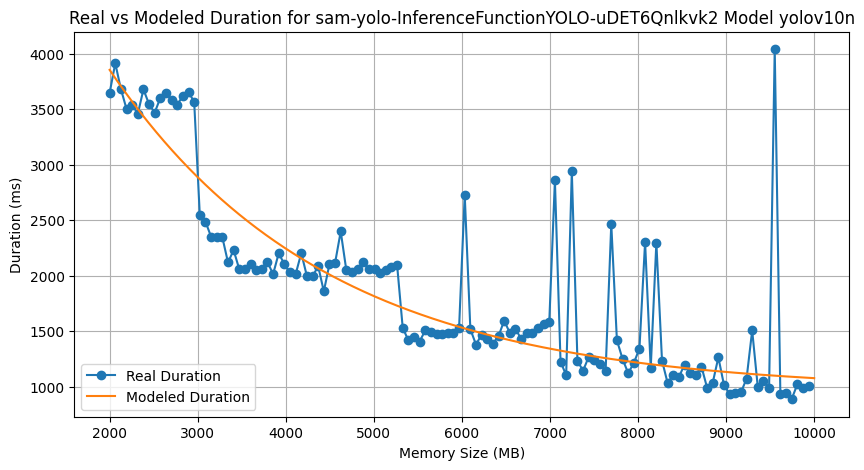

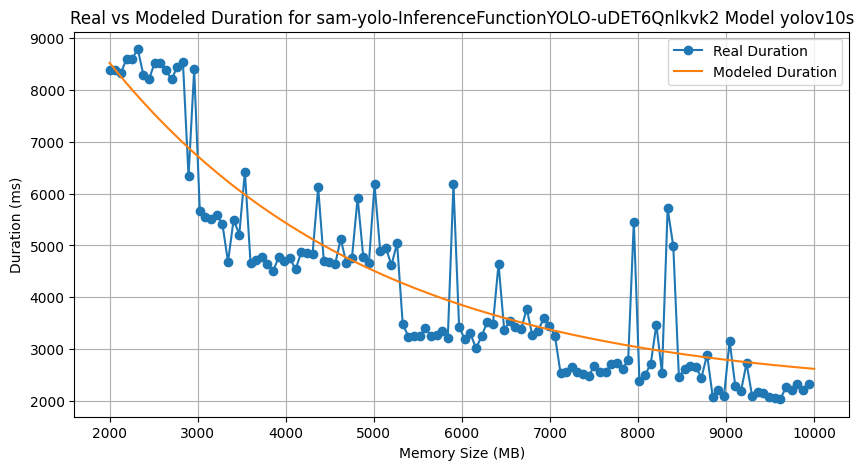

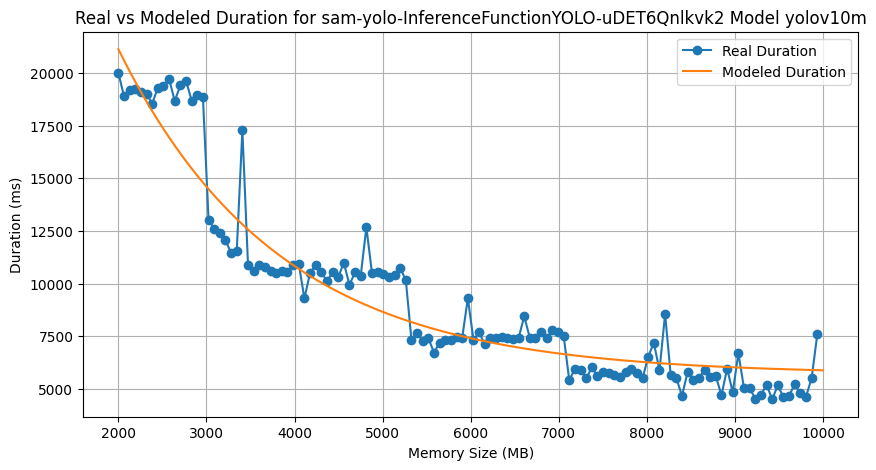

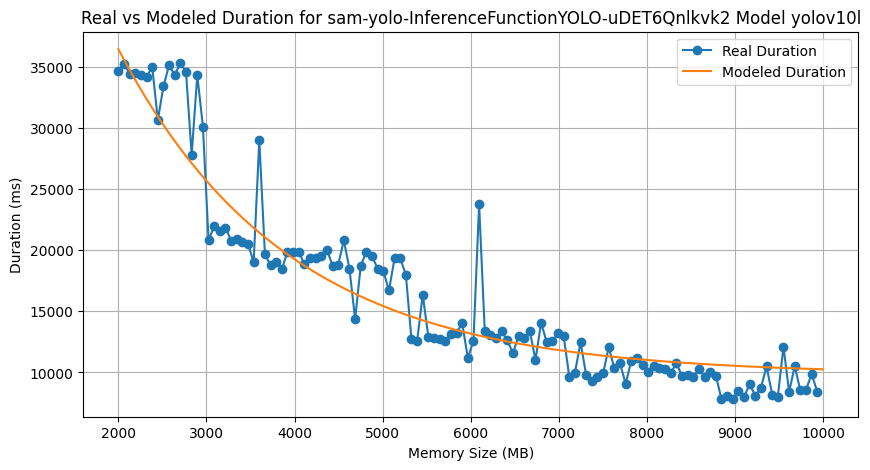

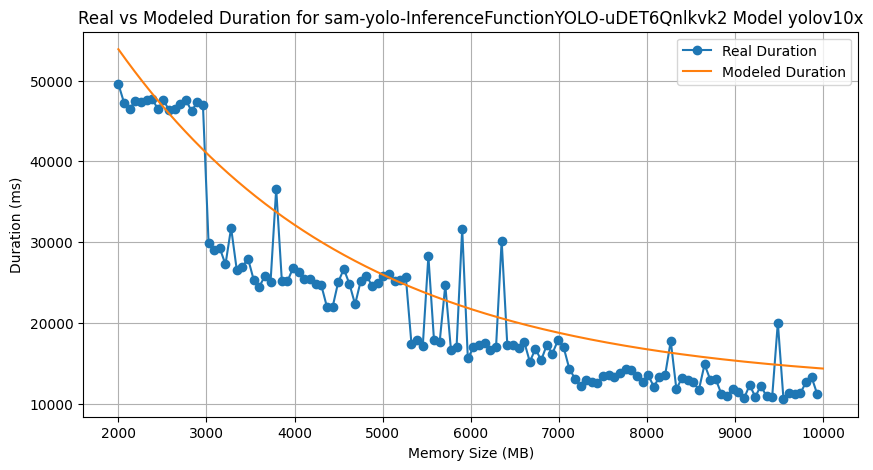

In [34]:
for i, model in enumerate(available_models):
    modeled_duration = modeled_durations[model]
    memory_bound = memeory_bounds[i]
    memory_space = np.arange(memory_bound[0], memory_bound[1] + 1)
    
    plt.figure(figsize=(10, 5))
    plt.plot(logs[model]['Memory Size'], logs[model]['Duration'], label='Real Duration', marker='o')
    plt.plot(memory_space, modeled_duration, label='Modeled Duration')
    plt.xlabel('Memory Size (MB)')
    plt.ylabel('Duration (ms)')
    plt.title(f'Real vs Modeled Duration for {function_name} Model {model}')
    plt.legend()
    plt.grid()

    plt.show()

In [37]:
for i, model in enumerate(available_models):
    modeled_duration = modeled_durations[model]
    memory_bound = memeory_bounds[i]
    memory_space = np.arange(memory_bound[0], memory_bound[1] + 1)
    
    # Extract real data
    real_memory_sizes = logs[model]['Memory Size']
    real_durations = logs[model]['Duration']
    
    # Compute modeled durations at the memory sizes from the logs.
    # Assuming memory sizes in logs are integers within the memory_bound range,
    # the index in modeled_duration can be computed as (mem_size - memory_bound[0]).
    modeled_at_real = [modeled_duration[int(mem - memory_bound[0])] for mem in real_memory_sizes]
    
    # Calculate the absolute errors and then the average error.
    errors = np.abs(np.array(real_durations) - np.array(modeled_at_real))
    avg_error = np.mean(errors)
    
    # Output the average error for the current model.
    print(f"Average error for model {model}: {avg_error:.2f} ms")

Average error for model yolov10n: 256.86 ms
Average error for model yolov10s: 643.01 ms
Average error for model yolov10m: 1081.38 ms
Average error for model yolov10l: 1852.57 ms
Average error for model yolov10x: 4356.92 ms


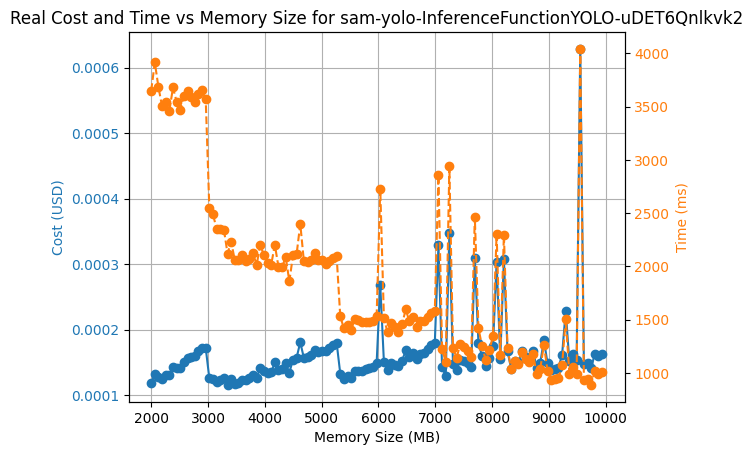

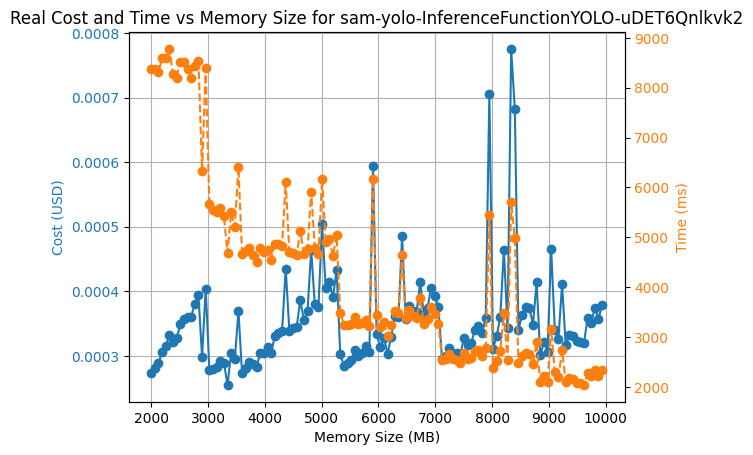

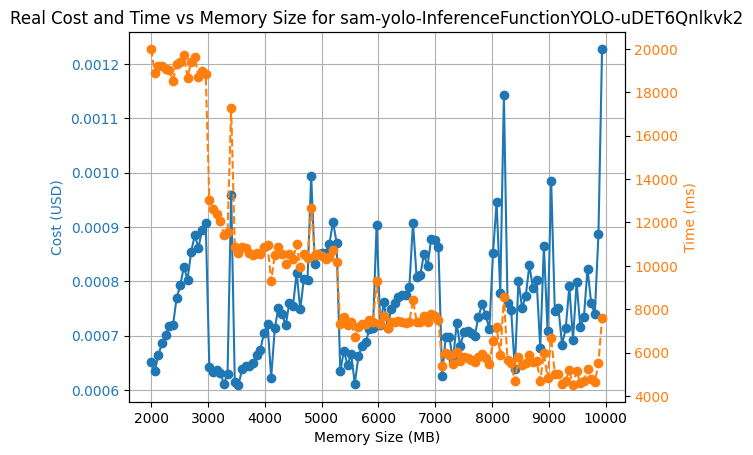

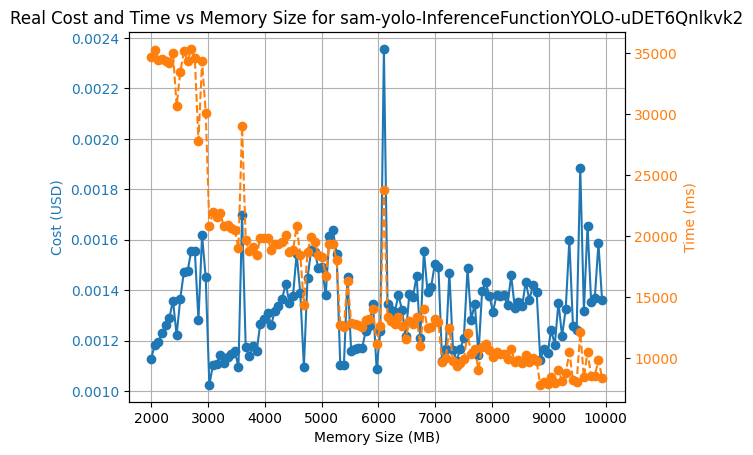

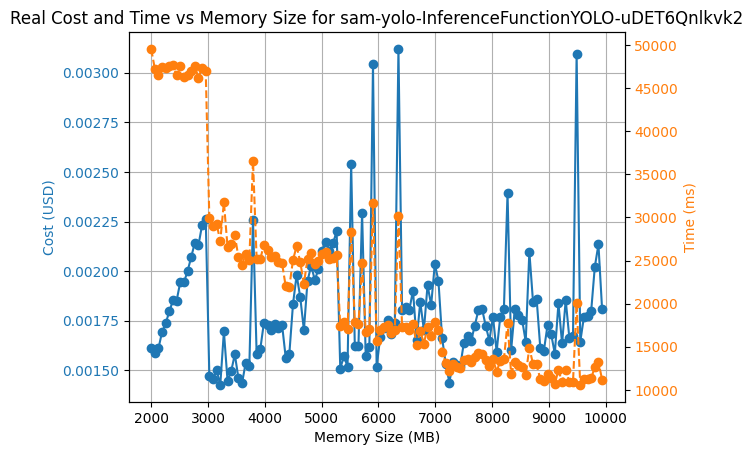

In [35]:
for i, model in enumerate(available_models):
    # Create figure and axis objects
    fig, ax1 = plt.subplots()

    # Plot Cost on the primary y-axis
    ax1.set_xlabel('Memory Size (MB)')
    ax1.set_ylabel('Cost (USD)', color='tab:blue')
    ax1.plot(logs[model]['Memory Size'], logs[model]['Cost'], color='tab:blue', marker='o', label='Cost')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Create a second y-axis for Time
    ax2 = ax1.twinx()
    ax2.set_ylabel('Time (ms)', color='tab:orange')
    ax2.plot(logs[model]['Memory Size'], logs[model]['Duration'], color='tab:orange', marker='o', linestyle='--', label='Time')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    # Add a title and grid
    plt.title('Real Cost and Time vs Memory Size for ' + function_name)
    ax1.grid(True)

    # Show plot
    plt.show()

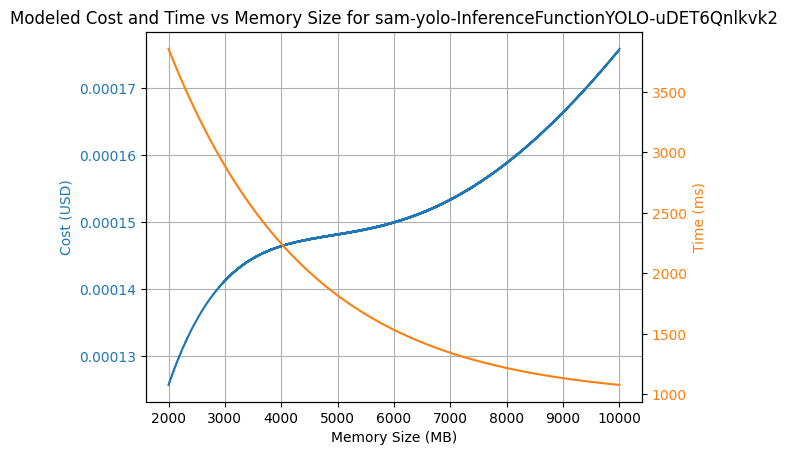

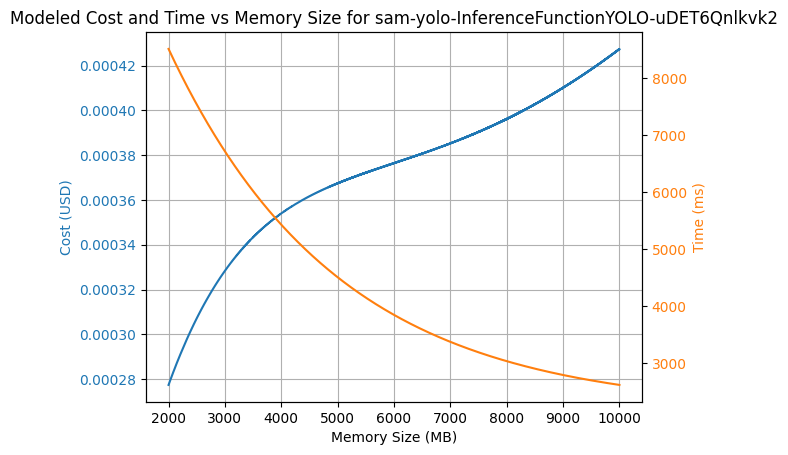

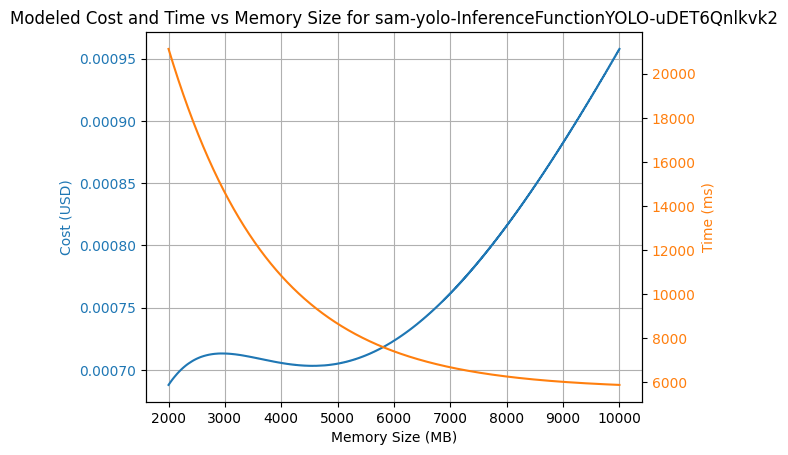

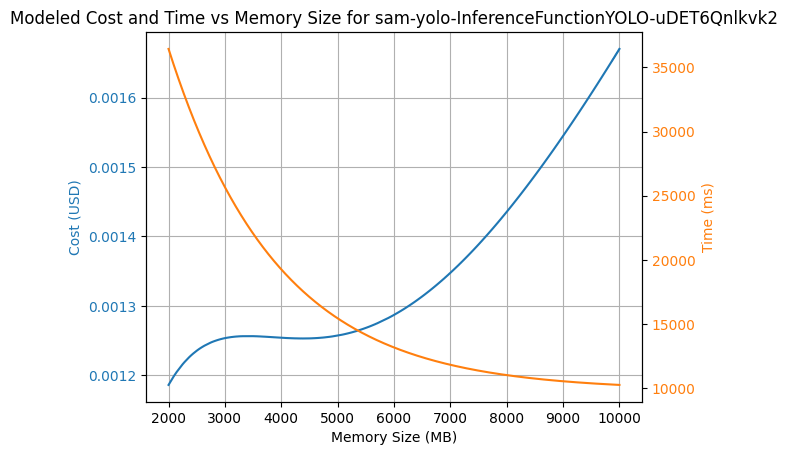

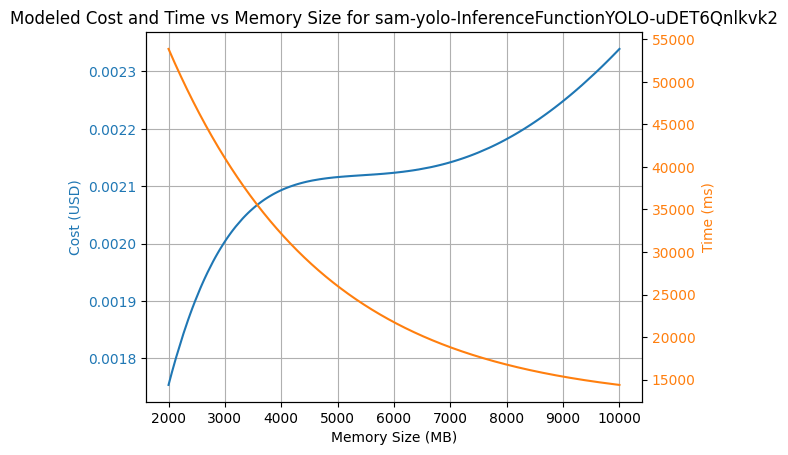

In [36]:
for i, model in enumerate(available_models):
    modeled_duration = modeled_durations[model]
    modeled_cost = modeled_costs[model]
    memory_bound = memeory_bounds[i]
    memory_space = np.arange(memory_bound[0], memory_bound[1] + 1)
    
    # Create figure and axis objects
    fig, ax1 = plt.subplots()


    # Plot Cost on the primary y-axis
    ax1.set_xlabel('Memory Size (MB)')
    ax1.set_ylabel('Cost (USD)', color='tab:blue')
    ax1.plot(memory_space, modeled_cost, color='tab:blue', label='Cost')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Create a second y-axis for Time
    ax2 = ax1.twinx()
    ax2.set_ylabel('Time (ms)', color='tab:orange')
    ax2.plot(memory_space, modeled_duration, color='tab:orange', label='Time')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    # Add a title and grid
    plt.title('Modeled Cost and Time vs Memory Size for ' + function_name)
    ax1.grid(True)

    # Show plot
    plt.show()